In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
from tqdm import tqdm
from bosperrus import *
plt.rcParams['svg.fonttype'] = 'none'
#plt.rcParams['figure.facecolor'] = "#D9D9D9"

from pathlib import Path
sys.path.insert(0, str((Path("..") / "src" / "utils").resolve()))
import micron_comparison

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
pal = FIT_PALETTE

In [4]:
cmap = "magma"

In [5]:
np.random.seed(41)

In [6]:
measure = "closeness"

In [7]:
with open("../mibitof_coords/coords.pickle", "rb") as f:
    datasets = pickle.load(f)

In [8]:
dataset = "TNBC_mibitof:p14_labeledcellData.tiff"
coords = datasets[dataset]

In [9]:
coords = coords[(coords[:, 0] < 1500) & (coords[:,1] < 1500)]
subset = coords /  (np.max(coords, axis=0) - np.min(coords, axis=0)) # [(coords[:, 0] < 1000) & (coords[:,1] < 1000)]

In [10]:
G = nx.Graph()
G.add_nodes_from(range(len(subset)))
for n in G.nodes:
    G.nodes[n]["pos"] = subset[n]
edges = delaunay_edges(subset)
G.add_edges_from(edges)

In [11]:
df =  pd.DataFrame(compute_centrality_measures(edges, len(subset), measures=[measure]))
df["distance"] = distance_to_convex_hull(subset)

In [12]:
d = df["distance"]
C_true = df[measure].values   

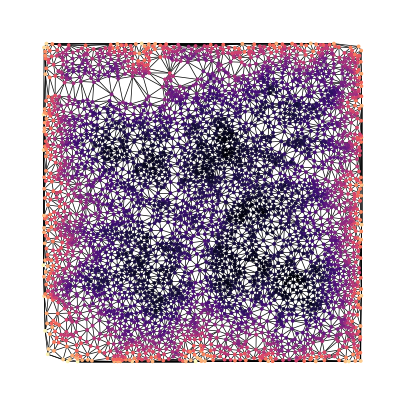

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
pos = nx.get_node_attributes(G, "pos")
edges1 = nx.draw_networkx_edges(G, pos=pos, ax=ax, edge_color="black", width=0.5)
nodes1 = nx.draw_networkx_nodes(G, pos=pos, node_color=C_true, node_size=3, cmap=cmap, ax=ax)
edges1.set_rasterized(True)
nodes1.set_rasterized(True)
plt.axis("square")
plt.axis("off")
plt.savefig("../result_plots/figure1/fig1_closeness.svg")

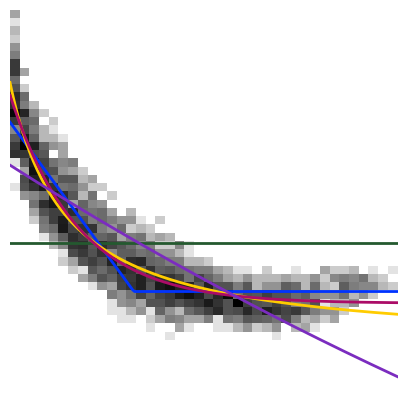

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))

fitted = []
for fit_cls in (ConstantFit, PiecewiseLinearFit, MichaelisMentenFit, ExponentialSaturationFit, ExponentialDecayFit):
    f = fit_cls(S_true=C_true, d=d)
    f.fit()
    fitted.append(f)

d_grid = np.linspace(np.min(d), np.max(d), 200)
plot_fit(ax, d, C_true, fitted[0].predict, d_grid=d_grid, line_kwargs={"color": pal[fitted[0].name], "label": fitted[0].name})
for f in fitted[1:]:
    ax.plot(d_grid, f.predict(d_grid), color=pal[f.name], label=f.name, linewidth=2)

ax.set_xlabel("")
ax.set_ylabel("")
ax.axis("off")
plt.savefig("../result_plots/figure1/fig1_fits.svg")

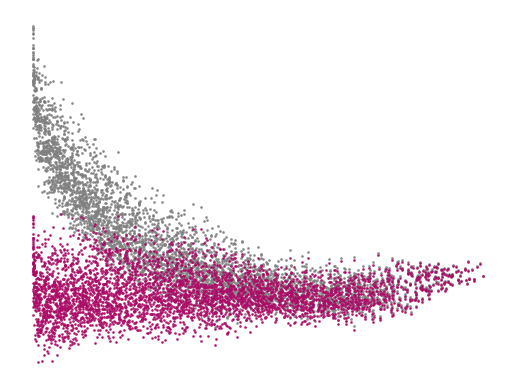

In [15]:
f = Flow.from_distances_and_scores(distances=d, scores=df[["closeness"]])
f.flow()
plt.scatter(d, C_true, label="Closeness", s=1, color="gray", alpha=0.8, rasterized=True)
plt.scatter(d, f.observations["BOSPERRUS corrected closeness"], label="BOSPERRUS corrected closeness", s=1, color=pal[f.best_fits["closeness"].name], alpha=0.8, rasterized=True)
plt.axis("off")
plt.savefig("../result_plots/figure1/fig1_corrections.svg")

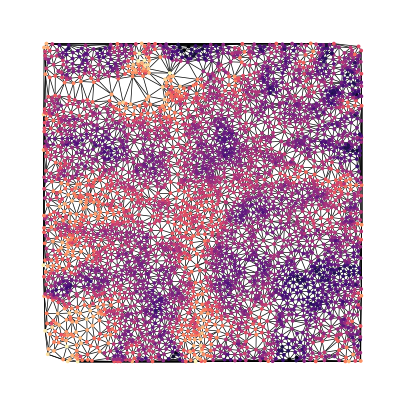

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
pos = nx.get_node_attributes(G, "pos")
edges1 = nx.draw_networkx_edges(G, pos=pos, ax=ax, edge_color="black", width=0.5)
nodes1 = nx.draw_networkx_nodes(G, pos=pos, node_color=f.observations["BOSPERRUS corrected closeness"], node_size=3, cmap=cmap, ax=ax)
edges1.set_rasterized(True)
nodes1.set_rasterized(True)
plt.axis("square")
plt.axis("off")

plt.savefig("../result_plots/figure1/fig1_corrected_closeness.svg")